# Data Preparation & Feature Engineering

This notebook is the **second stage** in the machine learning pipeline and builds directly upon the insights from our data exploration. Our goal here is to **prepare the dataset** for effective training by cleaning, transforming, and engineering features that enhance the learning signal.

---

### Notebook Objective

In this notebook, we aim to:
- Clean and normalize the raw dataset
- Split into Train/Validation/Test sets
- Convert categorical features to numerical format
- Handle missing values and ambiguous data entries
- Engineer useful features from existing columns
- Set up a reproducible ML preprocessing pipeline

This ensures the dataset is model-ready and consistent across experiments.

---

### Why This Matters

Data quality and representation directly affect model performance and fairness. A well-prepared dataset:
- Improves generalization
- Prevents data leakage
- Enables fair comparison between models
- Helps downstream explainability efforts

### Next Steps in the Workflow

The insights gathered here will directly inform the steps in the following notebooks:
- `03_model_training_and_evaluation.ipynb`
- `04_model_explainability.ipynb`
---
---


## Section 1 - Load Data & Initiate the DataFrame

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set(style='whitegrid')


In [2]:
import os
import sys
sys.path.append(os.path.abspath('..'))


In [3]:
# Importing the dataset into a DataFrame
df = pd.read_csv('../data/diabetes.csv')
# Creating a copy to not modify the original dataset
df_copy = df.copy()

# Displaying the first 10 rows of the copied DataFrame
df_copy.head(10)


,id,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,...,citoglipton,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted
0,1,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,...,No,No,No,No,No,No,No,No,No,NO
1,2,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,3,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,NO
3,4,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,5,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,6,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,7,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,8,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,...,No,No,No,No,No,No,No,No,Yes,>30
8,9,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,10,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
# Importing the custom functions, reloading the module to ensure the latest version is used
import importlib
import utils.functions as f

importlib.reload(f)


<module 'utils.functions' from 'c:\\Users\\Elias\\Documents\\Diabetes-readmission-ml-pipeline-main\\Diabetes-readmission-ml-pipeline-main\\utils\\functions.py'>

## Section 2 - Initial Data Cleaning: Handling Ambiguous & Missing Values

### 2.1 - Engineering Features that Requieres the Full Dataset 

In [5]:
# visit_frequency must be computed before dedup in clean_dataframe.
# Captures how many encounters each patient has in the full dataset.
# See Section 4 for full rationale and distribution analysis.
visit_frequency = df_copy['patient_nbr'].value_counts()
df_copy['visit_frequency'] = df_copy['patient_nbr'].map(visit_frequency)

Note on visit_frequency
This feature is computed here, before deduplication, because it requires the full dataset to count how many times each patient appears. Once deduplication runs, that information is lost.
Conceptually this is a feature engineering decision, a patient appearing frequently in the dataset likely has more chronic or severe disease, which may correlate with readmission risk. It is documented fully in Section 4.

### 2.2 - Identifying Placeholder Values and Setting them to NaN

In [6]:
# From the EDA and the ReadMe file, placeholder values are identiefied as missing values in the dataset. These values will be replaced with NaN for further processing.
placeholder_values = [
    'na', 'Na', 'NA',
    'NaN', 'nan', 'NAN',
    'n/a', 'N/A', 'n.a.',
    'N.A.', 'n.a', 'N.A',
    '?', '-', '--', '.', '*'
]

# Cleaning the DataFranme from placeholder values and dropping usless columns
df_nan, report = f.clean_dataframe(df_copy, placeholder_values)
df_clean, dropped_cols = f.drop_useless_columns(df_nan, threshold=0.40)

#  Verification
print("Cleaning Report:")
print(f"  Original: {report['original_shape']}")
print(f"  After global dedup: {report['after_global_dedup'][0]} rows (-{report['after_global_dedup'][1]})")
print(f"  After patient dedup: {report['after_patient_dedup'][0]} rows (-{report['after_patient_dedup'][1]})")
print(f"  Final: {report['final_shape']}")
print(f"  Dropped Columns: {dropped_cols}")

print(f"\nFinal shape: {df_clean.shape}")

Cleaning Report:
  Original: (101766, 52)
  After global dedup: 101766 rows (-0)
  After patient dedup: 71518 rows (-30248)
  Final: (71518, 52)
  Dropped Columns: ['weight', 'medical_specialty', 'payer_code', 'A1Cresult', 'max_glu_serum']

Final shape: (71518, 47)


In [7]:
df_clean.head()

,id,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,insulin,glyburide.metformin,glipizide.metformin,glimepiride.pioglitazone,metformin.rosiglitazone,metformin.pioglitazone,change,diabetesMed,readmitted,visit_frequency
0,1,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,...,No,No,No,No,No,No,No,No,NO,1
1,2,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,...,Up,No,No,No,No,No,Ch,Yes,>30,1
2,3,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,...,No,No,No,No,No,No,No,Yes,NO,1
3,4,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,...,Up,No,No,No,No,No,Ch,Yes,NO,1
4,5,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,...,Steady,No,No,No,No,No,Ch,Yes,NO,1


## Section 3 - Data Split & Imputation
Because we deduplicate to one row per patient before splitting, patient-level leakage between train/val/test is impossible by construction. An alternative approach, keeping all encounters and using GroupShuffleSplit on patient_nbr, would retain ~40% more data but introduces within-patient dependency in evaluation metrics. However, my current approach is chosen for clarity and should suffice for this kind of data set. 

### 3.1 Performing the Split

In [8]:
# Splitting the cleaned DataFrame into training and testing sets
X_train, X_val, X_test, y_train, y_val, y_test = f.data_split(df_clean, target_col='readmitted', random_state=42)

Data split completed successfully.
Shapes: Train 42910, Val 14304, Test 14304


### 3.2 - Exploration of the Splid Datasets

#### Verifying the Distributions

In [9]:
# Checking class distributions
print("Train balance:\n", y_train.value_counts(normalize=True))
print("\nVal balance:\n", y_val.value_counts(normalize=True))
print("\nTest balance:\n", y_test.value_counts(normalize=True))

Train balance:
 readmitted
NO     0.601049
>30    0.310976
<30    0.087975
Name: proportion, dtype: float64

Val balance:
 readmitted
NO     0.601021
>30    0.310962
<30    0.088017
Name: proportion, dtype: float64

Test balance:
 readmitted
NO     0.601021
>30    0.310962
<30    0.088017
Name: proportion, dtype: float64


#### Checking for Potential Data Leakage and Distribution of NaN values

In [10]:
# Check for leakage 
leakage = set(X_train.index).intersection(set(X_test.index))

if len(leakage) == 0:
    print("No common features across all sets. No leakage detected.")
else:
    print(f"Number of common features across all sets: {len(leakage)}")
    print(f"Common features: {leakage}")

# Confirm no numerical NaNs remain (categorical NaNs handled by imputer below)
assert X_train.select_dtypes(include='number').isnull().sum().sum() == 0
print("No numerical NaNs in train set. Categorical NaNs handled in imputation step.")

No common features across all sets. No leakage detected.
No numerical NaNs in train set. Categorical NaNs handled in imputation step.


#### Visualizing

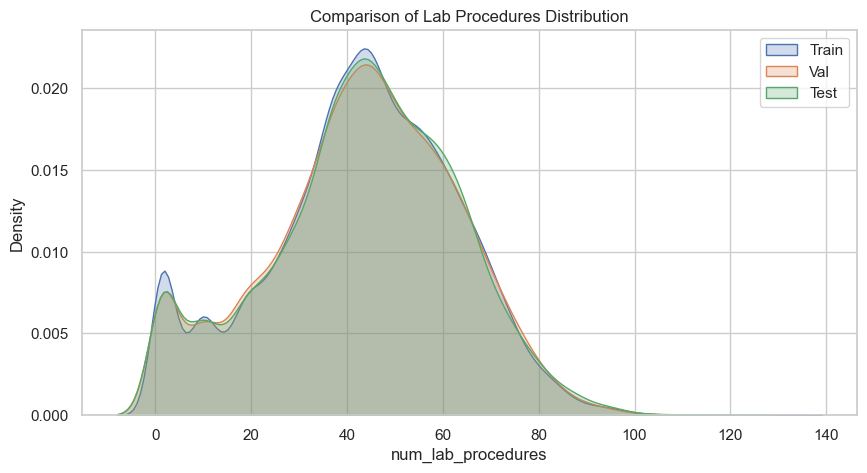

In [11]:
# Plotting the distribution of 'num_lab_procedures' 
plt.figure(figsize=(10, 5))
sns.kdeplot(X_train['num_lab_procedures'], label='Train', fill=True)
sns.kdeplot(X_val['num_lab_procedures'], label='Val', fill=True)
sns.kdeplot(X_test['num_lab_procedures'], label='Test', fill=True)
plt.title('Comparison of Lab Procedures Distribution')
plt.legend()
plt.show()

### 3.3 Imputation

#### Separating numerical and cathegorical data
The separation of cathegorical and numerical data is done manually as the methods used downstream are sensistive to these. For example, imputing the 'age' column results in wrong type and causes issues downstream. There are no robust functions that I trust enough to separate them, therefor we do this manually.

In [12]:
# Dropping identifiers because ofno predictive signal, and risk of the model memorizing individual patients instead of learning generalizable patterns.
X_train.drop(columns=['id', 'encounter_id', 'patient_nbr'], inplace=True)
X_val.drop(columns=['id', 'encounter_id', 'patient_nbr'], inplace=True)
X_test.drop(columns=['id', 'encounter_id', 'patient_nbr'], inplace=True)

# Defining the categorical and numerical columns for further processing
cat_cols = [
    'race', 'gender',
    'diag_1', 'diag_2', 'diag_3',
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
    'insulin', 'glyburide.metformin', 'glipizide.metformin',
    'glimepiride.pioglitazone', 'metformin.rosiglitazone',
    'metformin.pioglitazone', 'change', 'diabetesMed',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id'
]

num_cols = [
    'age', 'time_in_hospital', 'num_lab_procedures', 
    'num_procedures', 'num_medications', 'number_outpatient',
    'number_emergency', 'number_inpatient', 'number_diagnoses', 'visit_frequency'
]

#### Imputating the data, separated by type
In this case, for this specific data, we have noticed during the EDA that it has only missing values in the cathegorical features. Thus, there is no reason to imput any of the numerical ones, at all. If we had we would simply have done another imputer with "median" strategy, and should the need arise downstream we will apply it there. For now though, we do not have the need.

In [13]:
# Note: only categorical columns have missing values at this stage.
# most_frequent is appropriate here. If numerical NaNs appear in future,
# revisit with a ColumnTransformer using median for numerical columns.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X_train[cat_cols])

X_train = f.apply_imputer(X_train, imputer, cat_cols, num_cols)
X_val   = f.apply_imputer(X_val,   imputer, cat_cols, num_cols)
X_test  = f.apply_imputer(X_test,  imputer, cat_cols, num_cols)

print("NaN remaining after imputation:")
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

NaN remaining after imputation:
0
0
0


## Section 4 - Feature Engineering

### 4.1 - `visit_frequency`
`visit_frequency` captures how many times a patient appears in the full dataset. 
Patients with higher visit counts likely have more chronic or severe disease, 
which may correlate with readmission risk.

**Note on computation order:** This feature was computed in Section 2 before 
deduplication, as the full pre-dedup dataset is required to obtain accurate counts. 

**Limitation:** The dataset lacks reliable timestamps or explicit encounter ordering. 
This means we cannot claim this represents visits *prior* to the current encounter, 
it is a frequency signal, not a temporal one. It is treated as a property of the 
patient in this dataset rather than a strictly historical feature.

**Distribution:** Heavily right-skewed; approximately 54% of patients appear only 
once, with a long tail up to 28 encounters. Mean of 1.43 and median of 1 confirm 
the skew. This feature is retained as continuous to allow the model to leverage 
the full range of visit counts.

visit_frequency summary:
count    42910.000000
mean         1.425588
std          1.100784
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         28.000000
Name: visit_frequency, dtype: float64


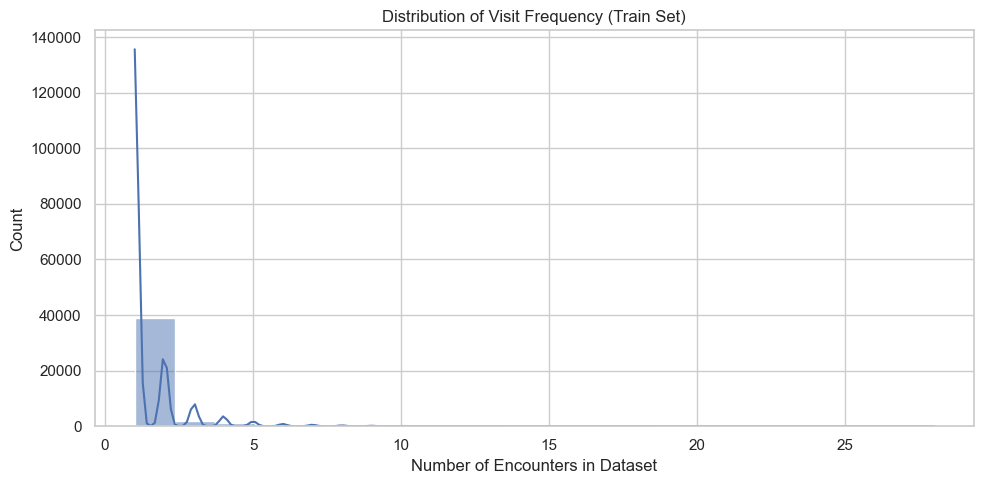

In [14]:
# Verifying visit_frequency carried through cleaning and split correctly
print('visit_frequency summary:')
print(X_train['visit_frequency'].describe())

# Plotting distribution
plt.figure(figsize=(10, 5))
sns.histplot(X_train['visit_frequency'], bins=20, kde=True)
plt.title('Distribution of Visit Frequency (Train Set)')
plt.xlabel('Number of Encounters in Dataset')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 4.2 Target Variable Transformation
The Target variable has three cathegories; No, <30 and >30, which points to if they have been readmitted within 30 days or not. For this project, we are interested in if a patient will be readmitted within 30 days or not. Thus, we can change it to a binary classification simply stating if a patient has been readmitted within 30 days (1) or not (0).

In [15]:
# Checking the target varuiable distribution in the training, validation and testing sets
print("Train balance:\n", y_train.value_counts(normalize=True))
print("\nVal balance:\n", y_val.value_counts(normalize=True))
print("\nTest balance:\n", y_test.value_counts(normalize=True))

Train balance:
 readmitted
NO     0.601049
>30    0.310976
<30    0.087975
Name: proportion, dtype: float64

Val balance:
 readmitted
NO     0.601021
>30    0.310962
<30    0.088017
Name: proportion, dtype: float64

Test balance:
 readmitted
NO     0.601021
>30    0.310962
<30    0.088017
Name: proportion, dtype: float64


In [16]:
y_train = f.binarize_target(y_train)
y_val = f.binarize_target(y_val)
y_test = f.binarize_target(y_test)

# Verifying the new target variable distribution
print("\nBinarized Train balance:\n", y_train.value_counts(normalize=True))
print("\nBinarized Val balance:\n", y_val.value_counts(normalize=True))
print("\nBinarized Test balance:\n", y_test.value_counts(normalize=True))


Binarized Train balance:
 readmitted
0    0.912025
1    0.087975
Name: proportion, dtype: float64

Binarized Val balance:
 readmitted
0    0.911983
1    0.088017
Name: proportion, dtype: float64

Binarized Test balance:
 readmitted
0    0.911983
1    0.088017
Name: proportion, dtype: float64


### 4.3 - `age`
The `age` feature is stored as categorical ranges (e.g. `[20-30)`). Converting it 
to numerical midpoints (e.g. 25) offers two advantages:

1. **Preserves ordinality** — the model can learn that 75 is meaningfully different 
from 45, rather than treating age groups as arbitrary unordered categories.
2. **Avoids encoding** — keeping it numerical means no additional dimensions are 
added, unlike one-hot encoding which would add 9 binary columns.

**Assumption:** We assume a linear relationship within each age bracket, that the 
midpoint is a reasonable representative value for the range. This is a standard 
simplification and acceptable given the 10-year bin width.

This is particularly relevant in a diabetic readmission context, where older patients 
are generally at higher risk; a signal that is better captured by a continuous 
value than a categorical label.

In [17]:
# Checking the current distribution of the 'age' feature in the training set
X_train['age'].value_counts(normalize=True).sort_index()

age
[0-10)      0.002330
[10-20)     0.007155
[20-30)     0.015870
[30-40)     0.037637
[40-50)     0.098439
[50-60)     0.174015
[60-70)     0.221394
[70-80)     0.254649
[80-90)     0.162293
[90-100)    0.026218
Name: proportion, dtype: float64

In [18]:
age_mapping = {
    '[0-10)': 5, '[10-20)': 15, '[20-30)': 25,
    '[30-40)': 35, '[40-50)': 45, '[50-60)': 55,
    '[60-70)': 65, '[70-80)': 75, '[80-90)': 85,
    '[90-100)': 95
}

X_train['age'] = X_train['age'].astype(str).map(age_mapping)
X_val['age'] = X_val['age'].astype(str).map(age_mapping)
X_test['age'] = X_test['age'].astype(str).map(age_mapping)

X_train['age'].value_counts(normalize=True).sort_index()


age
5     0.002330
15    0.007155
25    0.015870
35    0.037637
45    0.098439
55    0.174015
65    0.221394
75    0.254649
85    0.162293
95    0.026218
Name: proportion, dtype: float64

### 4.4 - Medication Activity Flags
We have roughly 23 features for different medications, each with roughly 4 values. 
Encoding them all would result in around 90+ new dimensions,  significant computational 
cost without clear benefit. Without domain expertise, we cannot justify that any single 
medication is a stronger predictor of readmission than another.

Instead, the dataset already contains `diabetesMed` which is a binary feature indicating 
whether the patient was on any diabetes medication. This captures the same signal 
we would have engineered, so all individual medication columns are dropped.

In [19]:
# Medical columns that were found in the dataset ReadMe file that shows whether the patient was on a specific medication or not. 
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton',
            'insulin', 'glyburide.metformin', 'glipizide.metformin',
            'glimepiride.pioglitazone', 'metformin.rosiglitazone',
            'metformin.pioglitazone']

# Dropping the medical columns
X_train.drop(columns=med_cols, inplace=True)
X_val.drop(columns=med_cols, inplace=True)
X_test.drop(columns=med_cols, inplace=True)

# Verify columns are droppedy
print(f"Remaining columns: {X_train.shape[1]}")
print(X_train.columns.tolist())

# Verify diabetesMed still there
print(X_train['diabetesMed'].value_counts())

Remaining columns: 20
['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'visit_frequency', 'race', 'gender', 'diag_1', 'diag_2', 'diag_3', 'change', 'diabetesMed', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
diabetesMed
Yes    32575
No     10335
Name: count, dtype: int64


### 4.5 - Diagnosis Mapping
The dataset contains three diagnosis features — `diag_1`, `diag_2`, and `diag_3`,
stored as raw ICD-9 codes with 700+ unique values, making them unusable in their 
raw form. We map them to broader disease categories based on ICD-9 code ranges 
(e.g. circulatory, respiratory, diabetes), reducing cardinality to ~11 categories 
which can then be one-hot encoded in Section 5.

`diag_1` is retained as the primary and most clinically significant diagnosis. 
`diag_2` and `diag_3` were considered but dropped for two reasons:

1. A comorbidity flag (`has_comorbidity`) was explored but rejected since 99.3% of 
patients have a secondary diagnosis, meaning the feature has near-zero variance 
and adds no predictive value.
2. Mapping and encoding all three features would add ~33 new dimensions with 
limited additional signal over `diag_1` alone.

In [20]:
icd9_mapped_categories = [
    (250, 250.99, "diabetes"),
    (390, 459, "circulatory"),
    (460, 519, "respiratory"),
    (520, 579, "digestive"),
    (580, 629, "genitourinary"),
    (240, 279, "endocrine"),
    (280, 289, "blood"),
    (320, 389, "nervous_system"),
    (780, 799, "symptoms"),
    (800, 999, "injury_poisoning"),
    (1, 139, "infectious"),
    (680, 709, "skin"),
]
# pregnancy, congenital, perinatal, mental_health, neoplasms, musculoskeletal → 'other'

X_train['diag_1'] = X_train['diag_1'].apply(lambda x: f.map_icd9(x, icd9_mapped_categories))
X_val['diag_1'] = X_val['diag_1'].apply(lambda x: f.map_icd9(x, icd9_mapped_categories))
X_test['diag_1'] = X_test['diag_1'].apply(lambda x: f.map_icd9(x, icd9_mapped_categories))

X_train.drop(columns=['diag_2', 'diag_3'], inplace=True)
X_val.drop(columns=['diag_2', 'diag_3'], inplace=True)
X_test.drop(columns=['diag_2', 'diag_3'], inplace=True)

In [21]:
print(X_train['diag_1'].isna().sum())
X_train['diag_1'].value_counts()

0


diag_1
circulatory         13159
other                5889
respiratory          4027
digestive            3879
diabetes             3445
symptoms             3278
injury_poisoning     2910
genitourinary        2109
endocrine            1131
infectious           1075
skin                 1074
nervous_system        536
blood                 398
Name: count, dtype: int64

### 4.6 - Binarization
Some features can be binarized instead of encoded in order to minimize dimensions. 
This is done here in feature engineering rather than Section 5, as these are 
deliberate feature design decisions rather than mechanical encoding steps.

Examples are `gender`, `change` and `diabetesMed`. Instead of one-hot encoding 
`gender` into multiple columns, we create a binary `is_male` feature. `change` 
indicates whether any medication was changed during the visit, we express this 
as a binary flag. `diabetesMed` is already a binary concept by definition, we 
simply convert it to numerical format.

In [22]:
# Gender
X_train['is_male'] = (X_train['gender'] == 'Male').astype(int)
X_val['is_male'] = (X_val['gender'] == 'Male').astype(int)
X_test['is_male'] = (X_test['gender'] == 'Male').astype(int)
X_train.drop(columns=['gender'], inplace=True)
X_val.drop(columns=['gender'], inplace=True)
X_test.drop(columns=['gender'], inplace=True)

# Change
X_train['change'] = (X_train['change'] == 'Ch').astype(int)
X_val['change'] = (X_val['change'] == 'Ch').astype(int)
X_test['change'] = (X_test['change'] == 'Ch').astype(int)

# diabetesMed
X_train['diabetesMed'] = (X_train['diabetesMed'] == 'Yes').astype(int)
X_val['diabetesMed'] = (X_val['diabetesMed'] == 'Yes').astype(int)
X_test['diabetesMed'] = (X_test['diabetesMed'] == 'Yes').astype(int)

In [23]:
# Verifying the new binary features distributions
print(X_train['is_male'].value_counts())
print(X_train['change'].value_counts())
print(X_train['diabetesMed'].value_counts())

# Checking the first few rows of the new binary features
X_train[['diabetesMed', 'change', 'is_male']].head()

is_male
0    22806
1    20104
Name: count, dtype: int64
change
0    23656
1    19254
Name: count, dtype: int64
diabetesMed
1    32575
0    10335
Name: count, dtype: int64


,diabetesMed,change,is_male
52753,1,1,1
34054,1,0,1
84025,1,0,0
9547,1,0,0
70564,1,0,0


### 4.7 - Dropping Rows With Low Frequency Categories
Some categorical columns contain codes or categories with very few instances,
in some cases single digits. These are too rare for the model to learn any meaningful 
pattern from, and keeping them would add noise without signal.

We drop these rows **only from the training set**. Validation and test sets are never 
modified — in a real deployment scenario you cannot filter out inconvenient inputs, 
so evaluation must reflect that reality. Rare categories in val and test will be 
handled by grouping into `other` during encoding in Section 5.

**Exception: expired/hospice patients (discharge codes 11, 13, 14) are removed from all sets including val and test. These patients cannot be readmitted by definition, so they aren't part of the prediction task. We assume that in deployment, such cases would be filtered upstream before reaching the model**

The threshold is set at 10 instances minimum. Columns affected:
- `admission_type_id` — codes 4 and 13
- `admission_source_id` — codes 10, 22, 25, 14, 11
- `gender` — `Unknown/Invalid` (1 instance)

Note: `discharge_disposition_id` rare categories are handled separately through 
feature grouping in Section 4.8, rather than row dropping, as the column has 
too many rare categories to address by dropping alone.

In [24]:
# ---------- admission_type_id ----------
idx_to_drop = f.get_rare_category_indices(X_train, 'admission_type_id', min_count=10)
X_train = X_train.drop(index=idx_to_drop)
y_train = y_train.drop(index=idx_to_drop)

# ---------- discharge_disposition_id ----------
# Drop expired (11) and hospice (13, 14) from ALL sets - these patients cannot be readmitted, so they are not relevant for the prediction task and can introduce noise.
invalid_codes = [11, 13, 14]

idx = X_train[X_train['discharge_disposition_id'].isin(invalid_codes)].index
X_train = X_train.drop(index=idx)
y_train = y_train.drop(index=idx)

idx = X_val[X_val['discharge_disposition_id'].isin(invalid_codes)].index
X_val = X_val.drop(index=idx)
y_val = y_val.drop(index=idx)

idx = X_test[X_test['discharge_disposition_id'].isin(invalid_codes)].index
X_test = X_test.drop(index=idx)
y_test = y_test.drop(index=idx)

# Drop remaining rare categories from train only
idx_to_drop = f.get_rare_category_indices(X_train, 'discharge_disposition_id', min_count=10)
X_train = X_train.drop(index=idx_to_drop)
y_train = y_train.drop(index=idx_to_drop)


# ---------- admission_source_id ----------
idx_to_drop = f.get_rare_category_indices(X_train, 'admission_source_id', min_count=10)
X_train = X_train.drop(index=idx_to_drop)
y_train = y_train.drop(index=idx_to_drop)


In [25]:
X_train['admission_type_id'].value_counts()

admission_type_id
1    21427
3     8184
2     7659
6     2669
5     1821
8      184
7       11
Name: count, dtype: int64

In [26]:
print(X_train['discharge_disposition_id'].value_counts().sort_index())

discharge_disposition_id
1     26571
2       909
3      5303
4       315
5       543
6      4964
7       231
8        41
15       26
18     1471
22      882
23      158
24       12
25      472
28       57
Name: count, dtype: int64


In [27]:
print(X_train['admission_source_id'].value_counts().sort_index())

admission_source_id
1     12944
2       548
3        82
4      1497
5       301
6      1070
7     22505
9        56
17     2860
20       92
Name: count, dtype: int64


### 4.8 - Grouping Similar Categories

Three columns; `admission_type_id`, `discharge_disposition_id`, and `admission_source_id`, contain numeric codes mapping to 9, 29, and 21 distinct values respectively. Encoding 
these directly would add too many dimensions with little benefit, as many codes are clinically similar or represent administrative placeholders.

We group them into meaningful clinical categories:

**`admission_type_id`** is grouped into `emergency`, `urgent`, `elective`, and `other` 
(covering NULL, Not Available, Not Mapped, and Trauma which has too few instances).

**`discharge_disposition_id`** — grouped into:
- `home` — discharged home with or without health services
- `care_facility` — transferred to SNF, ICF, rehab, long term care, or other inpatient facility
- `ama` — left against medical advice, known readmission risk factor
- `hospice` — discharged to hospice home or facility
- `other` — administrative codes, NULL, Not Mapped

**`admission_source_id`** is grouped into `emergency_room`, `referral` (physician, 
clinic, HMO), `transfer` (from hospital, SNF, or other facility), and `other` 
(NULL, Not Available, Not Mapped).

Any code not explicitly mapped falls to `other`, which also handles unseen 
codes in validation and test sets gracefully.

In [28]:
# discharge_disposition_id map
discharge_mapping = {
    1: 'home',
    6: 'home',
    8: 'home',
    2: 'care_facility',
    3: 'care_facility',
    4: 'care_facility',
    5: 'care_facility',
    22: 'care_facility',
    23: 'care_facility',
    24: 'care_facility',
    7: 'ama',
    15: 'other',
    18: 'other',
    25: 'other',
    28: 'other',
}

# admission_type_id map
admission_mapping = {
    1: 'emergency',
    2: 'urgent',
    3: 'elective',
    5: 'other',
    6: 'other',
    7: 'other',
    8: 'other',
}

# admission_source_id map
source_mapping = {
    7: 'emergency_room',
    1: 'referral',
    2: 'referral',
    3: 'referral',
    4: 'transfer',
    5: 'transfer',
    6: 'transfer',
    17: 'other',
    9: 'other',
    20: 'other',
}


In [29]:
X_train['discharge_disposition_id'] = X_train['discharge_disposition_id'].map(discharge_mapping).fillna('other')
X_val['discharge_disposition_id'] = X_val['discharge_disposition_id'].map(discharge_mapping).fillna('other')
X_test['discharge_disposition_id'] = X_test['discharge_disposition_id'].map(discharge_mapping).fillna('other')

X_train['admission_type_id'] = X_train['admission_type_id'].map(admission_mapping).fillna('other')
X_val['admission_type_id'] = X_val['admission_type_id'].map(admission_mapping).fillna('other')
X_test['admission_type_id'] = X_test['admission_type_id'].map(admission_mapping).fillna('other')

X_train['admission_source_id'] = X_train['admission_source_id'].map(source_mapping).fillna('other')
X_val['admission_source_id'] = X_val['admission_source_id'].map(source_mapping).fillna('other')
X_test['admission_source_id'] = X_test['admission_source_id'].map(source_mapping).fillna('other')

In [30]:
print(f"Discharge Disposition ID counts: {X_train['discharge_disposition_id'].value_counts().sort_index().to_dict()}")
print(f"Admission Type ID counts: {X_train['admission_type_id'].value_counts().sort_index().to_dict()}")
print(f"Admission Source ID counts: {X_train['admission_source_id'].value_counts().sort_index().to_dict()}")

Discharge Disposition ID counts: {'ama': 231, 'care_facility': 8122, 'home': 31576, 'other': 2026}
Admission Type ID counts: {'elective': 8184, 'emergency': 21427, 'other': 4685, 'urgent': 7659}
Admission Source ID counts: {'emergency_room': 22505, 'other': 3008, 'referral': 13574, 'transfer': 2868}


### 4.9 - Final Checks 


In [31]:
print(X_train.shape)
print(X_train.columns.tolist())
print(X_train.isnull().sum().sum())

(41955, 18)
['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'visit_frequency', 'race', 'diag_1', 'change', 'diabetesMed', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'is_male']
0


## Section 5 - Encoding

In [32]:
# Checking the features we have after the preprocessing and feature engineering steps
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41955 entries, 52753 to 79374
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   age                       41955 non-null  int64 
 1   time_in_hospital          41955 non-null  int64 
 2   num_lab_procedures        41955 non-null  int64 
 3   num_procedures            41955 non-null  int64 
 4   num_medications           41955 non-null  int64 
 5   number_outpatient         41955 non-null  int64 
 6   number_emergency          41955 non-null  int64 
 7   number_inpatient          41955 non-null  int64 
 8   number_diagnoses          41955 non-null  int64 
 9   visit_frequency           41955 non-null  int64 
 10  race                      41955 non-null  object
 11  diag_1                    41955 non-null  object
 12  change                    41955 non-null  int64 
 13  diabetesMed               41955 non-null  int64 
 14  admission_type_id      

In [33]:
cat_cols = ['race', 'diag_1', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id']
X_train, X_val, X_test = f.encode_categorical(X_train, X_val, X_test, cat_cols)

In [34]:
# Again, checking what features we have after encoding the categorical features
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41955 entries, 52753 to 79374
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   age                                     41955 non-null  int64  
 1   time_in_hospital                        41955 non-null  int64  
 2   num_lab_procedures                      41955 non-null  int64  
 3   num_procedures                          41955 non-null  int64  
 4   num_medications                         41955 non-null  int64  
 5   number_outpatient                       41955 non-null  int64  
 6   number_emergency                        41955 non-null  int64  
 7   number_inpatient                        41955 non-null  int64  
 8   number_diagnoses                        41955 non-null  int64  
 9   visit_frequency                         41955 non-null  int64  
 10  change                                  41955 non-null  int

## Section 6 - Standardizing the Data

#### Standardizing the Non-Binary Numerical Data Using StandardScaler

In [35]:
# Since we dont need to scale the binary features, we will only scale the numerical features. 
cols_to_scale = [
    'age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_outpatient', 'number_emergency', 
    'number_inpatient', 'number_diagnoses', 'visit_frequency'
]

# Scaling the numerical features using StandardScaler, fit on the training set and applied to all sets to prevent data leakage.
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

#### Final check

In [36]:
# Shape check
print(X_train.shape, X_val.shape, X_test.shape)

# No NaNs
print(X_train.isnull().sum().sum())
print(X_val.isnull().sum().sum())
print(X_test.isnull().sum().sum())

# Dtypes - should be all numerical now
print(X_train.dtypes.unique())

# Scale check - train should be ~0 mean, ~1 std for scaled columns
print(X_train[cols_to_scale].mean().round(2))
print(X_train[cols_to_scale].std().round(2))

# Index alignment
assert list(X_train.index) == list(y_train.index)
assert list(X_val.index) == list(y_val.index)
assert list(X_test.index) == list(y_test.index)
print("Index alignment OK")

(41955, 38) (13993, 38) (13981, 38)
0
0
0
[dtype('float64') dtype('int64')]
age                   0.0
time_in_hospital     -0.0
num_lab_procedures   -0.0
num_procedures       -0.0
num_medications       0.0
number_outpatient     0.0
number_emergency      0.0
number_inpatient      0.0
number_diagnoses     -0.0
visit_frequency      -0.0
dtype: float64
age                   1.0
time_in_hospital      1.0
num_lab_procedures    1.0
num_procedures        1.0
num_medications       1.0
number_outpatient     1.0
number_emergency      1.0
number_inpatient      1.0
number_diagnoses      1.0
visit_frequency       1.0
dtype: float64
Index alignment OK


## Section 7 - Saving the Pre-Processed Data

In [37]:
import os

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('../data/processed/X_train.csv', index=True)
X_val.to_csv('../data/processed/X_val.csv', index=True)
X_test.to_csv('../data/processed/X_test.csv', index=True)
y_train.to_csv('../data/processed/y_train.csv', index=True)
y_val.to_csv('../data/processed/y_val.csv', index=True)
y_test.to_csv('../data/processed/y_test.csv', index=True)

print("Data saved successfully")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Data saved successfully
X_train: (41955, 38), y_train: (41955,)
X_val: (13993, 38), y_val: (13993,)
X_test: (13981, 38), y_test: (13981,)
